In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from team_wtm import eda

pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = eda.load_data()
print(f"rows: {len(df):,}")

rows: 59,400


## 1. Target-class distribution

*Tasks: analyse `status_group`, class counts and percentages, visualise, investigate imbalance.*

In [3]:
counts = df["status_group"].value_counts().reindex(eda.STATUS_ORDER)
target = pd.DataFrame({"count": counts, "percent": (100 * counts / counts.sum()).round(1)})
target

,count,percent
status_group,,
functional,32259,54.3
functional needs repair,4317,7.3
non functional,22824,38.4


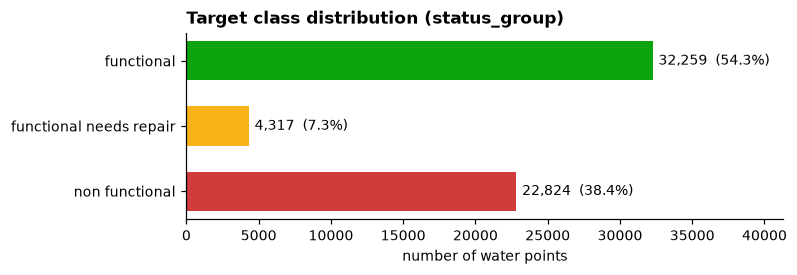

In [4]:
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.barh(counts.index[::-1], counts.values[::-1],
        color=[eda.STATUS_COLORS[s] for s in counts.index[::-1]], height=0.6)
for y, (n, p) in enumerate(zip(counts.values[::-1], target["percent"].values[::-1])):
    ax.text(n + 400, y, f"{n:,}  ({p:.1f}%)", va="center", fontsize=9)
ax.set_xlim(0, counts.max() * 1.28)
ax.set_xlabel("number of water points")
ax.set_title("Target class distribution (status_group)", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
eda.save(fig, "5_01_target_distribution");

In [5]:
# imbalance: how many times larger is the biggest class than each class?
imbalance = (counts.max() / counts).round(1).rename("majority / class ratio")
imbalance

status_group
functional                 1.0
functional needs repair    7.5
non functional             1.4
Name: majority / class ratio, dtype: float64

**Observations**
- 54.3% functional, 38.4% non functional, only **7.3% functional needs repair**.
- The majority class is about **7.5× larger** than "needs repair" → clear **class imbalance**.
- A model that always predicts "functional" already gets ~54% accuracy, so **accuracy alone is misleading**.

**For modelling (Sprint 2):** report per-class precision/recall/F1 and the confusion matrix;
use stratified train/test split and CV; try `class_weight="balanced"` or resampling for "needs repair".

## 2. Which categorical features are most associated with status?

*Task: explore important categorical features.*

**Cramér's V** measures the strength of association between two categorical variables
(0 = none, 1 = perfect). Columns with very many categories are grouped to top 30 + "other" first,
because many tiny categories inflate the value.

,feature,cramers_v,categories
0,quantity,0.309,5
1,waterpoint_type,0.250,7
2,extraction_type,0.249,18
3,extraction_type_class,0.242,7
4,funder,0.198,1896
5,payment_type,0.183,7
6,installer,0.179,2145
7,source,0.149,10
8,water_quality,0.138,8
9,quality_group,0.133,6


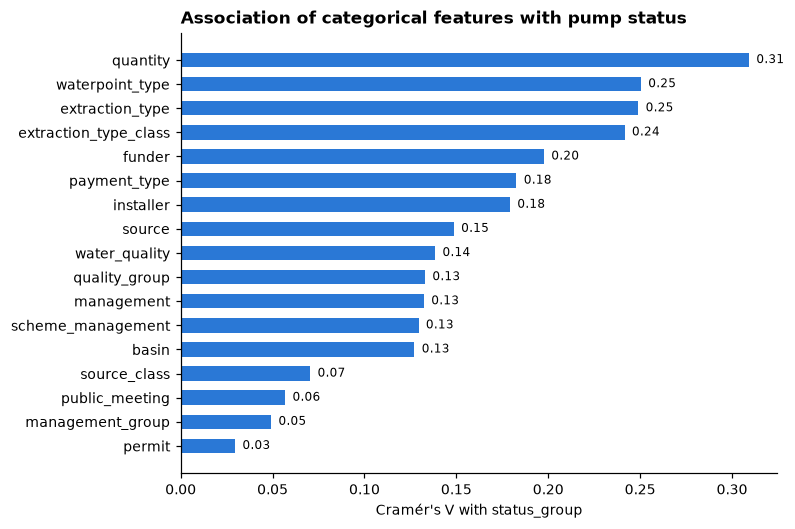

In [6]:
cat_cols = [
    "quantity", "waterpoint_type", "extraction_type", "extraction_type_class",
    "payment_type", "water_quality", "quality_group", "source", "source_class",
    "management", "management_group", "scheme_management", "public_meeting", "permit",
    "basin", "installer", "funder",
]
rows = []
for c in cat_cols:
    x = df[c].astype("object").fillna("missing")
    if x.nunique() > 30:
        x = eda.lump_rare(x, top=30)
    rows.append((c, eda.cramers_v(x, df["status_group"]), df[c].nunique()))
assoc = pd.DataFrame(rows, columns=["feature", "cramers_v", "categories"]).sort_values("cramers_v")

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.barh(assoc["feature"], assoc["cramers_v"], color="#2a78d6", height=0.6)
for y, v in enumerate(assoc["cramers_v"]):
    ax.text(v + 0.004, y, f"{v:.2f}", va="center", fontsize=8)
ax.set_xlabel("Cramér's V with status_group")
ax.set_title("Association of categorical features with pump status", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
eda.save(fig, "5_02_cramers_v_ranking");
assoc.sort_values("cramers_v", ascending=False).round(3).reset_index(drop=True)

## 3. Pump / extraction type and water-point type

*Task: compare pump functionality across pump or extraction types.*

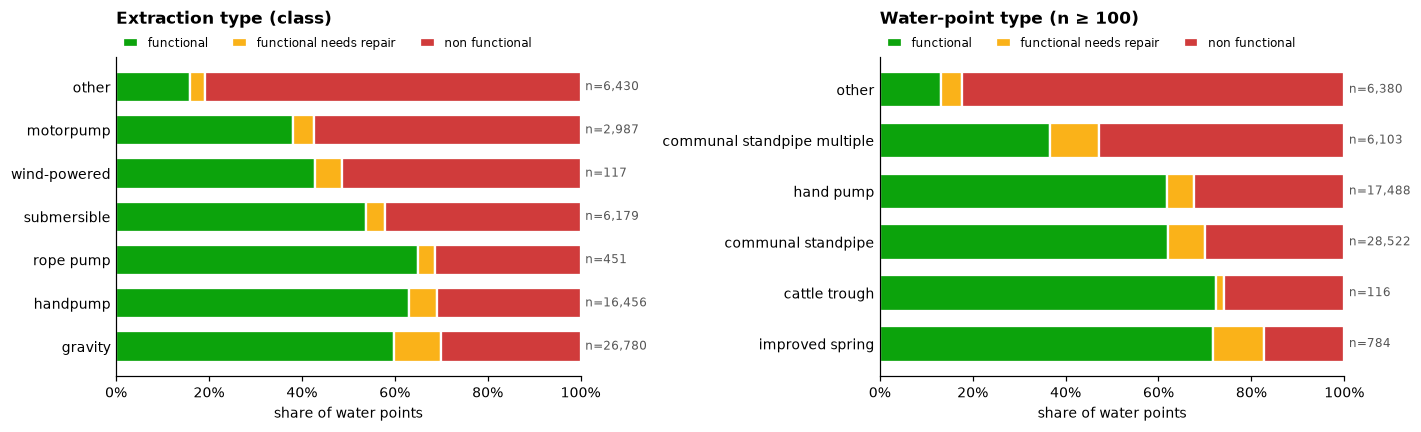

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
eda.plot_status_bars(eda.status_share(df, "extraction_type_class"), "Extraction type (class)", ax=axes[0])
eda.plot_status_bars(eda.status_share(df, "waterpoint_type", min_count=100), "Water-point type (n ≥ 100)", ax=axes[1])
fig.tight_layout()
eda.save(fig, "5_03_extraction_waterpoint");

In [8]:
# detailed extraction_type (18 values) – more detail inside 'handpump' and 'other'
eda.status_share(df, "extraction_type", min_count=100).round(3)

status_group,functional,functional needs repair,non functional,n
extraction_type,,,,
nira/tanira,0.665,0.079,0.257,8154
afridev,0.678,0.024,0.298,1770
gravity,0.599,0.101,0.300,26780
other - rope pump,0.650,0.038,0.313,451
india mark ii,0.603,0.033,0.364,2400
swn 80,0.569,0.058,0.373,3670
submersible,0.551,0.048,0.401,4764
other - swn 81,0.524,0.031,0.445,229
ksb,0.497,0.018,0.485,1415


**Observations**
- Gravity, handpump and rope pump: ~60–65% functional.
- **"other"** extraction (≈ 80% non functional) and water-point type **"other"** (≈ 82%) stand out strongly.
- Motor pumps and wind-powered pumps are below average (~38–43% functional).
- "Communal standpipe multiple" (53% non functional) is clearly worse than "communal standpipe" (30%).

## 4. Water source

*Task: investigate water source.*

status_group,functional,functional needs repair,non functional,n
source,,,,
rainwater harvesting,0.604,0.137,0.259,2295
spring,0.622,0.075,0.303,17021
river,0.569,0.127,0.304,9612
other,0.594,0.005,0.401,212
hand dtw,0.569,0.019,0.412,874
shallow well,0.495,0.057,0.448,16824
unknown,0.485,0.061,0.455,66
machine dbh,0.490,0.044,0.466,11075
dam,0.386,0.037,0.578,656


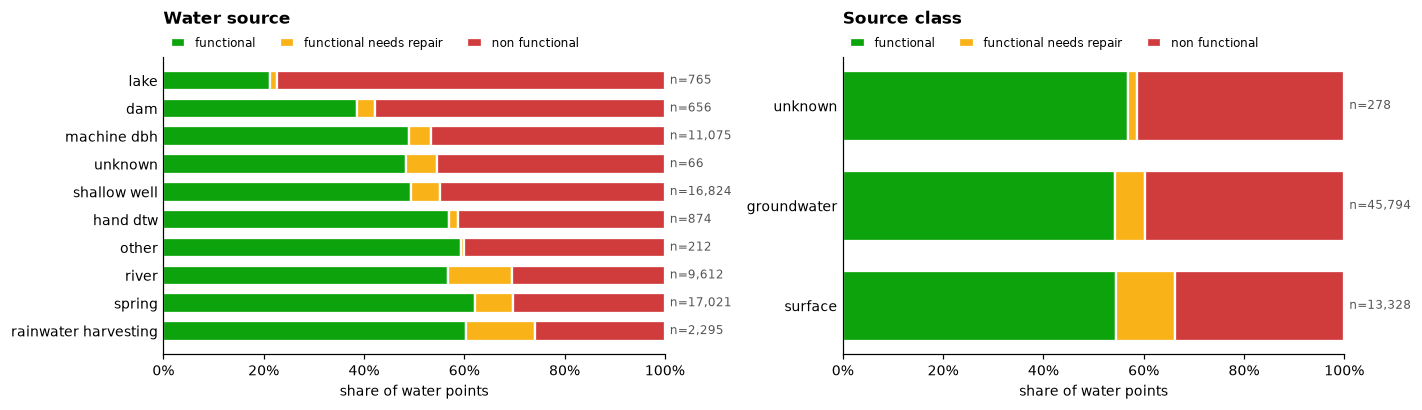

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
eda.plot_status_bars(eda.status_share(df, "source"), "Water source", ax=axes[0])
eda.plot_status_bars(eda.status_share(df, "source_class"), "Source class", ax=axes[1])
fig.tight_layout()
eda.save(fig, "5_04_source");
eda.status_share(df, "source").round(3)

**Observations**
- Springs (62%) and rainwater harvesting (60%) have the most functional points.
- **Lakes (77% non functional)** and **dams (58%)** stand out; shallow wells and machine-drilled boreholes are also above average (45–47%).
- `source_class` (groundwater vs surface) shows only a small difference → the detailed `source` column carries more information.
- Surface sources have a higher **needs repair** share than groundwater.

## 5. Water quantity and quality

*Task: investigate water quantity and quality.*

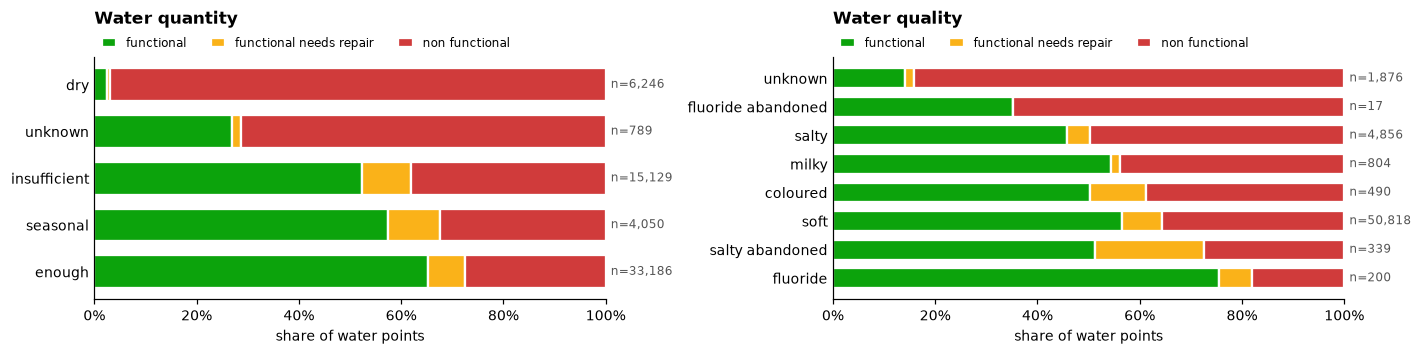

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.3))
eda.plot_status_bars(eda.status_share(df, "quantity"), "Water quantity", ax=axes[0])
eda.plot_status_bars(eda.status_share(df, "water_quality"), "Water quality", ax=axes[1])
fig.tight_layout()
eda.save(fig, "5_05_quantity_quality");

In [11]:
print("quantity == quantity_group in every row:", (df["quantity"] == df["quantity_group"]).all())
eda.status_share(df, "quantity").round(3)

quantity == quantity_group in every row: True


status_group,functional,functional needs repair,non functional,n
quantity,,,,
enough,0.652,0.072,0.275,33186
seasonal,0.574,0.103,0.323,4050
insufficient,0.523,0.096,0.381,15129
unknown,0.270,0.018,0.712,789
dry,0.025,0.006,0.969,6246


**Observations**
- `quantity` has the **strongest association** of all features (Cramér's V ≈ 0.31).
- **97% of "dry" water points are non functional**; "enough" water has the most functional points (65%).
- ⚠️ The direction is unclear: a point may be recorded as "dry" *because* it does not deliver water.
  This could act like **target leakage** – PM-4 should compare models with and without it.
- Water quality: "unknown" (84% non functional) and salty water stand out; "unknown" quality and "unknown" quantity may mark points that were not working at inspection.
- `quantity` and `quantity_group` are identical → keep only one.

## 6. Management-related variables

*Task: investigate management-related variables.*

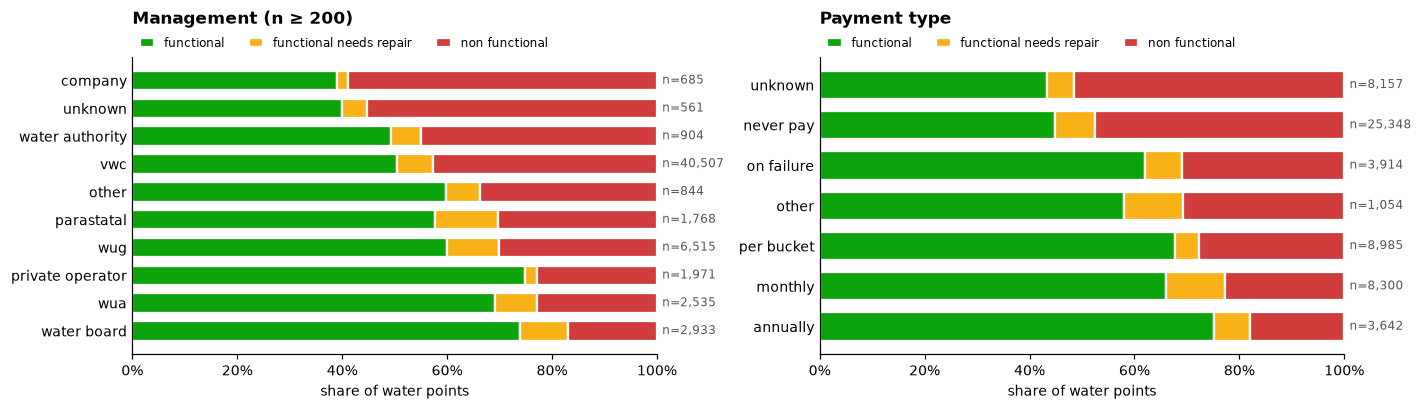

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
eda.plot_status_bars(eda.status_share(df, "management", min_count=200), "Management (n ≥ 200)", ax=axes[0])
eda.plot_status_bars(eda.status_share(df, "payment_type"), "Payment type", ax=axes[1])
fig.tight_layout()
eda.save(fig, "5_06_management_payment");

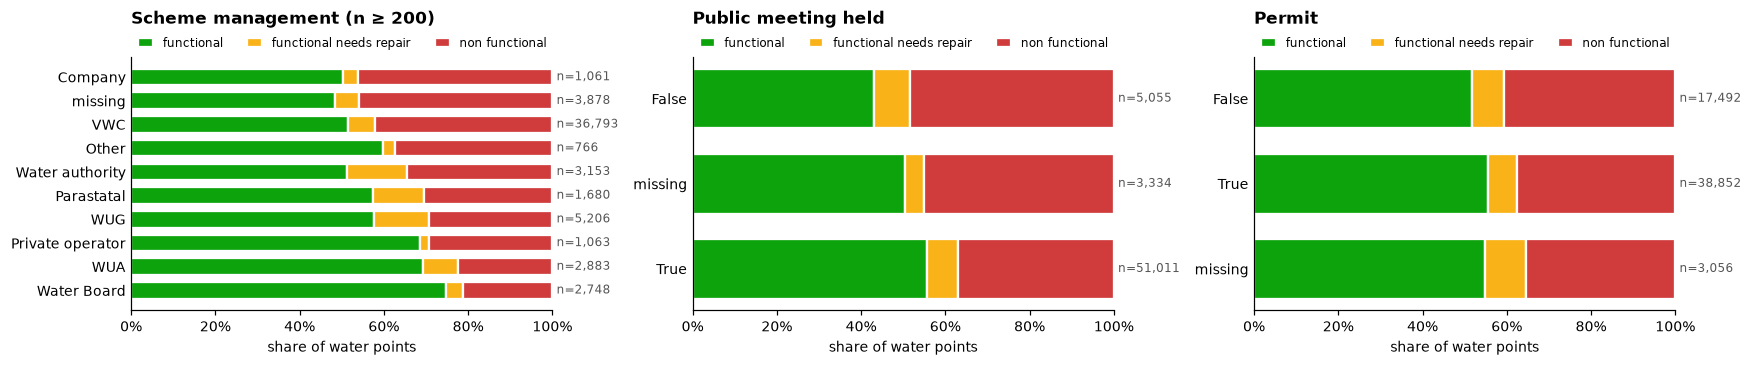

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
eda.plot_status_bars(eda.status_share(df, "scheme_management", min_count=200), "Scheme management (n ≥ 200)", ax=axes[0])
eda.plot_status_bars(eda.status_share(df, "public_meeting"), "Public meeting held", ax=axes[1])
eda.plot_status_bars(eda.status_share(df, "permit"), "Permit", ax=axes[2])
fig.tight_layout()
eda.save(fig, "5_07_scheme_meeting_permit");

**Observations**
- **Payment shows a clear pattern:** where users pay (annually, monthly, per bucket) 66–75% of points are functional;
  where they **never pay**, only 45% (48% non functional).
  A possible explanation is that fees fund repairs – but payment could also be stopped *after* a pump breaks, so we cannot say which way it goes.
- Management type: water boards, WUAs and private operators have ~17–23% non functional, while **VWC** (village water committees,
  68% of all points) has 43% and companies 59%. Because VWC is so dominant, the overall association is moderate (V ≈ 0.13).
- `public_meeting = False` goes with more failures; `permit` shows almost no difference (Cramér's V ≈ 0.03).

## 7. Installer and funder

*Task: investigate installer/funder variables where appropriate.*

In [14]:
for c in ["installer", "funder"]:
    raw_n = df[c].nunique()
    clean = eda.clean_text(df[c])
    cover = [clean.value_counts().head(k).sum() / len(clean) for k in (10, 20, 50)]
    print(f"{c:10s} unique raw: {raw_n:5,}  after lower-case: {clean.nunique():5,}  "
          f"top10/20/50 cover: {cover[0]:.0%} / {cover[1]:.0%} / {cover[2]:.0%}")

installer  unique raw: 2,145  after lower-case: 1,934  top10/20/50 cover: 52% / 61% / 73%
funder     unique raw: 1,896  after lower-case: 1,896  top10/20/50 cover: 44% / 55% / 70%


In [15]:
# example of the spelling problem
inst = df["installer"].dropna()
inst[inst.str.lower().str.contains("gov")].value_counts().head(10)

installer
Government             1825
Central government      622
Gover                   383
Gove                    222
Central govt            138
GOVER                   128
Central Government      110
GOVERNMENT               66
Tanzania Government      33
GOVERN                   27
Name: count, dtype: int64

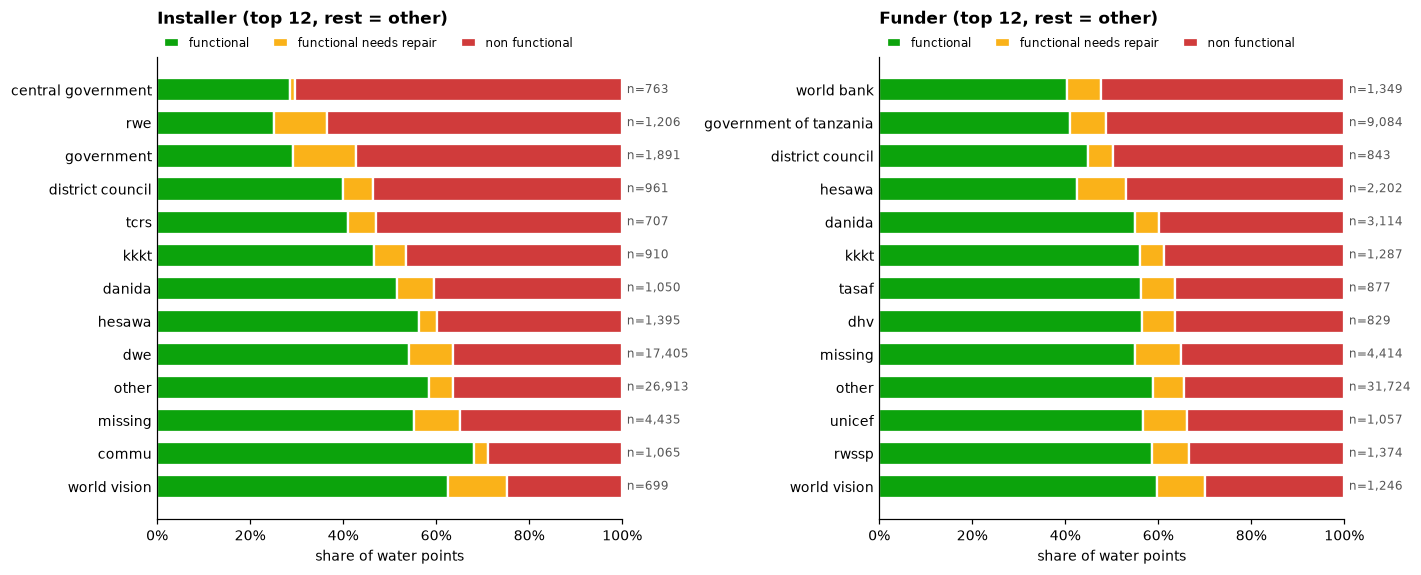

In [16]:
tmp = df.assign(installer_top=eda.lump_rare(df["installer"], top=12),
                funder_top=eda.lump_rare(df["funder"], top=12))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
eda.plot_status_bars(eda.status_share(tmp, "installer_top"), "Installer (top 12, rest = other)", ax=axes[0])
eda.plot_status_bars(eda.status_share(tmp, "funder_top"), "Funder (top 12, rest = other)", ax=axes[1])
fig.tight_layout()
eda.save(fig, "5_08_installer_funder");

**Observations**
- 2,000+ installers and ~1,900 funders, with many spellings of the same name ("Government", "GOVER", "Gove", …).
- Among large installers the non functional share ranges from **~25% (World Vision, community)** to **~70% (Central government)**.
  DWE, the largest installer (17k points), is close to average.
- So these columns carry information, but only after **text cleaning + grouping**.

## 8. High-cardinality variables

*Task: identify high-cardinality variables that may require grouping.*

In [17]:
obj_cols = df.select_dtypes(exclude="number").columns.drop(["status_group", "date_recorded"])
card = (df[obj_cols].nunique().rename("unique values").to_frame()
          .assign(top10_cover=lambda t: [df[c].value_counts().head(10).sum() / len(df) for c in t.index])
          .sort_values("unique values", ascending=False))
card["suggestion"] = pd.cut(card["unique values"], [0, 30, 200, 1e6],
                            labels=["keep as is (one-hot)", "group / target-encode", "group top-N + other, or drop"])
card.round(2)

,unique values,top10_cover,suggestion
wpt_name,37399,0.14,"group top-N + other, or drop"
subvillage,19287,0.05,"group top-N + other, or drop"
scheme_name,2695,0.06,"group top-N + other, or drop"
installer,2145,0.44,"group top-N + other, or drop"
ward,2092,0.04,"group top-N + other, or drop"
funder,1896,0.38,"group top-N + other, or drop"
lga,125,0.21,group / target-encode
region,21,0.65,keep as is (one-hot)
extraction_type,18,0.99,keep as is (one-hot)
extraction_type_group,13,0.99,keep as is (one-hot)


**Observations**
- Very high (likely drop or heavy grouping): `wpt_name`, `subvillage`, `scheme_name`, `ward`.
- High but useful after grouping: `installer`, `funder`, `lga` → top-N + "other" (or target encoding in Sprint 2).
- Several columns repeat the same information at different detail levels
  (`extraction_type` / `_group` / `_class`, `payment` / `payment_type`, `water_quality` / `quality_group`,
  `source` / `source_type` / `source_class`, `waterpoint_type` / `_group`, `management` / `management_group`)
  → choose one per group in Sprint 2. `recorded_by` has only one value.

## 9. Which categories have the most "needs repair"?

The "needs repair" class is the most interesting for preventive maintenance and the hardest to predict.
Categories with at least 300 points and the highest needs-repair share:

In [18]:
rows = []
for c in ["quantity", "waterpoint_type", "extraction_type", "source", "water_quality",
          "payment_type", "management", "scheme_management", "basin"]:
    t = eda.status_share(df, c, min_count=300)
    for cat, r in t.iterrows():
        rows.append((c, cat, r["functional needs repair"], int(r["n"])))
nr = pd.DataFrame(rows, columns=["feature", "category", "needs_repair_share", "n"])
overall = df["needs_repair"].mean()
print(f"overall needs repair share: {overall:.1%}")
nr.sort_values("needs_repair_share", ascending=False).head(12).round(3).reset_index(drop=True)

overall needs repair share: 7.3%


,feature,category,needs_repair_share,n
0,water_quality,salty abandoned,0.212,339
1,scheme_management,Water authority,0.142,3153
2,source,rainwater harvesting,0.137,2295
3,scheme_management,WUG,0.129,5206
4,source,river,0.127,9612
5,scheme_management,Parastatal,0.120,1680
6,management,parastatal,0.119,1768
7,basin,Lake Tanganyika,0.115,6432
8,payment_type,other,0.112,1054
9,payment_type,monthly,0.112,8300


**Observations**
- Needs repair is 7.3% overall, but reaches **12–21%** in some groups: *salty abandoned* water (21%),
  surface sources (river 13%, rainwater harvesting 14%), water authority / WUG / parastatal management (12–14%),
  and the Lake Tanganyika and Lake Rukwa basins (11%).
- No single feature separates "needs repair" well; even the best groups are still mostly functional.
  This confirms that this class will be hard to predict and needs special attention in Sprint 2.

## 10. Summary – support or challenge the hypotheses

| Hypothesis | Result | Evidence |
|---|---|---|
| Pump / extraction type is associated with functionality | ✅ supported | "other" ≈ 80% non functional vs gravity/handpump ≈ 60–65% functional |
| Water quantity and quality are associated with status | ✅ strongly supported | 97% of *dry* points non functional; quantity has highest Cramér's V (0.31) |
| Management structure is associated with functionality | ⚠️ partly | payment type clear (18% vs 48% non functional); management type weaker |
| Installer / funder give useful information | ✅ supported, but messy | ~25% to ~70% non functional across large installers; needs cleaning |
| Water source is associated with status | ✅ moderate | detailed `source` matters, `source_class` much less |
| Permit is associated with status | ❌ challenged | almost no difference (V ≈ 0.03) |

### Findings relevant for modelling (Sprint 2)
1. **Class imbalance** (needs repair 7.3%) → per-class metrics, stratified CV, class weights.
2. **Strongest categorical signals:** quantity, waterpoint type, extraction type, installer/funder (grouped), payment type.
3. **Possible leakage:** `quantity = dry`, and "unknown" categories – test with and without.
4. **Redundant columns:** keep one column per group; drop `quantity_group`, `recorded_by`.
5. **High-cardinality:** clean text, group `installer` / `funder` / `lga` to top-N + "other"; drop ID-like text columns.

All findings are associations; they do not prove that one variable causes pump failure.